# Sleeper Fantasy Football - League Exploration Notebook
**League:** The Few, The Proud  
**League ID:** `1365771765128663040`  
**API Documentation:** [Sleeper API Docs](https://docs.sleeper.com/)

Use this notebook to explore league data, inspect raw JSON from Sleeper endpoints, analyze standings, and experiment with custom charts and power rankings.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pre-configured League ID
LEAGUE_ID = "1365771765128663040"
BASE_URL = "https://api.sleeper.app/v1"

print(f"Exploring Sleeper League: {LEAGUE_ID}")

Exploring Sleeper League: 1365771765128663040


## 1. League Details & Settings
Inspect the league metadata, season, roster composition, and playoff configuration.

In [2]:
league = requests.get(f"{BASE_URL}/league/{LEAGUE_ID}").json()

print("=== League Information ===")
print("Name:", league.get("name"))
print("Season:", league.get("season"))
print("Total Teams:", league.get("total_rosters"))
print("Status:", league.get("status"))
print("Playoff Teams:", league.get("settings", {}).get("playoff_teams"))
print("Playoff Start Week:", league.get("settings", {}).get("playoff_week_start"))
print("Roster Positions:", ", ".join(league.get("roster_positions", [])))

=== League Information ===
Name: The Few, The Proud
Season: 2026
Total Teams: 12
Status: in_season
Playoff Teams: 6
Playoff Start Week: 15
Roster Positions: QB, RB, RB, WR, WR, TE, FLEX, FLEX, K, DEF, BN, BN, BN, BN, BN, BN


## 2. Standings & Team Roster Breakdown
Combine the `/users` and `/rosters` endpoints to build a clean Pandas DataFrame of all teams, their records, points scored, and remaining FAAB.

In [3]:
users = requests.get(f"{BASE_URL}/league/{LEAGUE_ID}/users").json()
rosters = requests.get(f"{BASE_URL}/league/{LEAGUE_ID}/rosters").json()

user_map = {u["user_id"]: u for u in users}
l_settings = league.get("settings") or {}
l_meta = league.get("metadata") or {}
waiver_budget = l_settings.get("waiver_budget", 100)

teams_data = []
for r in rosters:
    u = user_map.get(r.get("owner_id")) or {}
    u_meta = u.get("metadata") or {}
    r_meta = r.get("metadata") or {}
    r_settings = r.get("settings") or {}
    rid = r.get("roster_id")
    
    team_name = u_meta.get("team_name") or u.get("display_name") or f"Team {rid}"
    fpts = r_settings.get("fpts", 0) + (r_settings.get("fpts_decimal", 0) / 100)
    fpts_against = r_settings.get("fpts_against", 0) + (r_settings.get("fpts_against_decimal", 0) / 100)
    
    div_id = r_settings.get("division")
    div_name = l_meta.get(f"division_{div_id}", "") if div_id else ""
    
    teams_data.append({
        "Roster ID": rid,
        "Team Name": team_name,
        "Manager": u.get("display_name", "Unknown"),
        "Division": div_name,
        "Wins": r_settings.get("wins", 0),
        "Losses": r_settings.get("losses", 0),
        "Ties": r_settings.get("ties", 0),
        "Points For": round(fpts, 2),
        "Points Against": round(fpts_against, 2),
        "Streak": r_meta.get("streak", "-"),
        "FAAB Remaining": waiver_budget - r_settings.get("waiver_budget_used", 0),
        "Starters Count": len(r.get("starters") or []),
        "Total Players": len(r.get("players") or [])
    })

df_standings = pd.DataFrame(teams_data)
df_standings = df_standings.sort_values(by=["Wins", "Points For"], ascending=False).reset_index(drop=True)
df_standings.index = df_standings.index + 1
df_standings.index.name = "Rank"
df_standings

,Roster ID,Team Name,Manager,Division,Wins,Losses,Ties,Points For,Points Against,Streak,FAAB Remaining,Starters Count,Total Players
Rank,,,,,,,,,,,,,
1,1,DEZekiel2517,DEZekiel2517,Hold Our Beers!,0,0,0,0.0,0.0,-,100,10,16
2,2,DEZpicableMe2,DEZpicableMe2,Next Level,0,0,0,0.0,0.0,-,100,10,16
3,3,GoDEZurself,GoDEZUrself,Hold Our Beers!,0,0,0,0.0,0.0,-,100,10,16
4,4,DEZpacito1,DEZpacito1,Next Level,0,0,0,0.0,0.0,-,100,10,16
5,5,WhoDaHellDezThat,WhoDaHellDezThat,Hold Our Beers!,0,0,0,0.0,0.0,-,100,10,16
6,6,DezCheez,DezCheez,Hold Our Beers!,0,0,0,0.0,0.0,-,100,10,16
7,7,DEZisHoweDoit!,Dezishowedoit,Next Level,0,0,0,0.0,0.0,-,100,10,16
8,8,DEZcantstopme,DEZcantstopme,Next Level,0,0,0,0.0,0.0,-,100,10,16
9,9,DezWuzRobbed,DEZwuzrobbed,Hold Our Beers!,0,0,0,0.0,0.0,-,100,10,16


## 3. Weekly Head-to-Head Matchup Analysis
Fetch matchup data for any given week to see head-to-head scores and victory margins.

In [4]:
def get_weekly_matchups(week=1):
    matchups = requests.get(f"{BASE_URL}/league/{LEAGUE_ID}/matchups/{week}").json()
    roster_lookup = {t["Roster ID"]: t["Team Name"] for t in teams_data}
    
    grouped = {}
    for m in matchups:
        mid = m.get("matchup_id")
        if mid is None:
            continue
        grouped.setdefault(mid, []).append(m)
    
    rows = []
    for mid, teams_in_matchup in grouped.items():
        if len(teams_in_matchup) == 2:
            t1, t2 = teams_in_matchup[0], teams_in_matchup[1]
            s1, s2 = t1.get("points", 0), t2.get("points", 0)
            name1 = roster_lookup.get(t1["roster_id"], f"Team {t1['roster_id']}")
            name2 = roster_lookup.get(t2["roster_id"], f"Team {t2['roster_id']}")
            
            winner = name1 if s1 > s2 else (name2 if s2 > s1 else "Tie")
            rows.append({
                "Matchup ID": mid,
                "Team 1": name1,
                "Score 1": s1,
                "Team 2": name2,
                "Score 2": s2,
                "Margin": round(abs(s1 - s2), 2),
                "Winner": winner if (s1 > 0 or s2 > 0) else "Upcoming"
            })
    return pd.DataFrame(rows)

# Check Week 1
df_week1 = get_weekly_matchups(1)
df_week1

,Matchup ID,Team 1,Score 1,Team 2,Score 2,Margin,Winner
0,4,DEZekiel2517,0.0,DezWhatImTalkingBout,0.0,0.0,Upcoming
1,6,DEZpicableMe2,0.0,DEZnotnice,0.0,0.0,Upcoming
2,2,GoDEZurself,0.0,DEZcantstopme,0.0,0.0,Upcoming
3,3,DEZpacito1,0.0,DezWuzRobbed,0.0,0.0,Upcoming
4,5,WhoDaHellDezThat,0.0,DEZisHoweDoit!,0.0,0.0,Upcoming
5,1,DezCheez,0.0,DezUnfortuneNATE,0.0,0.0,Upcoming


## 4. Visualizations: Points For vs. Points Against
A classic fantasy football chart: Teams in the top-left have high scoring and easy schedules (lucky), while teams in the bottom-right have low scoring and tough schedules (unlucky).

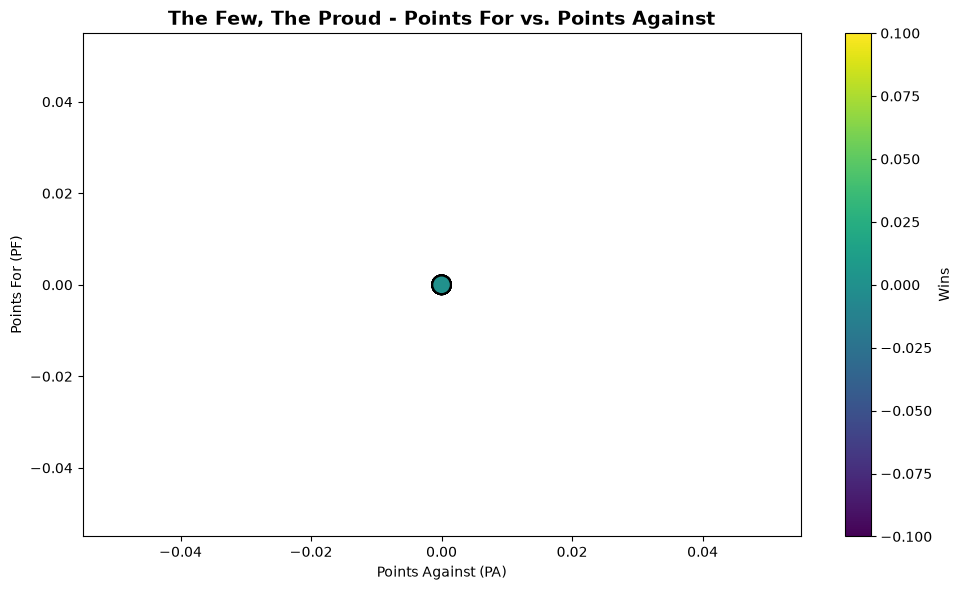

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_standings["Points Against"],
    df_standings["Points For"],
    s=180,
    c=df_standings["Wins"],
    cmap="viridis",
    edgecolors="black",
    linewidth=1.5
)

for _, row in df_standings.iterrows():
    ax.annotate(
        row["Team Name"],
        (row["Points Against"] + 0.5, row["Points For"] + 0.5),
        fontsize=9
    )

ax.set_title(f"{league.get('name', 'League')} - Points For vs. Points Against", fontsize=14, fontweight="bold")
ax.set_xlabel("Points Against (PA)")
ax.set_ylabel("Points For (PF)")
cbar = plt.colorbar(scatter)
cbar.set_label("Wins")
plt.tight_layout()
plt.show()